In [2]:
import kagglehub
bhavikjikadara_dog_and_cat_classification_dataset_path = kagglehub.dataset_download('bhavikjikadara/dog-and-cat-classification-dataset')

print('Data source import complete.')

Data source import complete.


In [3]:
print(bhavikjikadara_dog_and_cat_classification_dataset_path)

/kaggle/input/dog-and-cat-classification-dataset


In [4]:
import os
dataset_root = f"{bhavikjikadara_dog_and_cat_classification_dataset_path}"
print(os.listdir(dataset_root))

['PetImages']


In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split

# ✅ Updated dataset path (from kagglehub)
input_dir = '/kaggle/input/dog-and-cat-classification-dataset/PetImages'

# ✅ Output directory for split data
output_base = '/content/split_data'  # Colab writable area
train_dir = os.path.join(output_base, 'train')
test_dir = os.path.join(output_base, 'test')

# Create output directories
for subdir in ['train/cats', 'train/dogs', 'test/cats', 'test/dogs']:
    os.makedirs(os.path.join(output_base, subdir), exist_ok=True)

# Gather image paths and labels
image_paths = []
labels = []

for label in ['Cat', 'Dog']:
    full_path = os.path.join(input_dir, label)
    for fname in os.listdir(full_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            fpath = os.path.join(full_path, fname)
            # Skip broken files
            try:
                with open(fpath, 'rb') as f:
                    f.read()
                image_paths.append(fpath)
                labels.append('cats' if label == 'Cat' else 'dogs')
            except:
                continue

# Split dataset
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

# Copy files to train/test folders
def copy_images(paths, labels, dest_dir):
    for path, label in zip(paths, labels):
        try:
            shutil.copy(path, os.path.join(dest_dir, label, os.path.basename(path)))
        except:
            continue

copy_images(train_paths, train_labels, train_dir)
copy_images(test_paths, test_labels, test_dir)

print("✅ Split complete.")
print(f"Train set: {len(train_paths)} images")
print(f"Test set:  {len(test_paths)} images")

✅ Split complete.
Train set: 19998 images
Test set:  5000 images


Using device: cuda
Training samples: 19998
Testing samples: 5000


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]
/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/10
  Train Loss: 0.1191, Train Acc: 0.9560
  Val Loss:   0.0618, Val Acc:   0.9766


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 2/10
  Train Loss: 0.0783, Train Acc: 0.9696
  Val Loss:   0.0541, Val Acc:   0.9810


...

Epoch 8/10
  Train Loss: 0.0699, Train Acc: 0.9731
  Val Loss:   0.0513, Val Acc:   0.9812


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 9/10
  Train Loss: 0.0711, Train Acc: 0.9722
  Val Loss:   0.0516, Val Acc:   0.9806


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 10/10
  Train Loss: 0.0708, Train Acc: 0.9735
  Val Loss:   0.0549, Val Acc:   0.9796

Classification Report (ResNet18):
              precision    recall  f1-score   support

        cats       0.97      0.99      0.98      2500
        dogs       0.99      0.97      0.98      2500

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



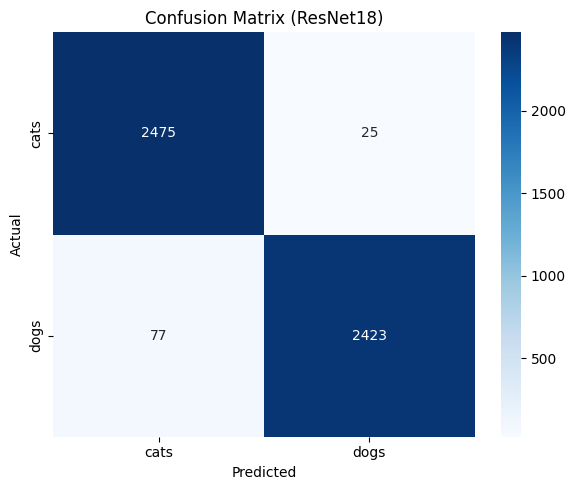

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Data transforms (same as before for consistency)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet standard input size
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 3. Dataset directories
train_dir = '/content/split_data/train'
test_dir = '/content/split_data/test'

# 4. Datasets and loaders
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

# 5. Load pretrained ResNet18 and freeze all layers
resnet = models.resnet18(pretrained=True)
for param in resnet.parameters():
    param.requires_grad = False  # freeze feature extractor

# 6. Replace final fully connected layer
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 2)  # binary classification
resnet = resnet.to(device)

# 7. Loss and optimizer (only train final layer)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.fc.parameters(), lr=0.001)

# 8. Train function
def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

# 9. Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_labels, all_preds

# 10. Training loop
epochs = 10
for epoch in range(epochs):
    train_loss, train_acc = train(resnet, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_labels, val_preds = evaluate(resnet, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

# 11. Classification Report
print("\nClassification Report (ResNet18):")
print(classification_report(val_labels, val_preds, target_names=train_dataset.classes))

# 12. Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap="Blues")
plt.title("Confusion Matrix (ResNet18)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()